In [2]:
import pandas as pd

# List of file paths
file_paths = [f'000{i}.parquet' for i in range(6)]

# Load and combine data
dataframes = [pd.read_parquet(file) for file in file_paths]
full_data = pd.concat(dataframes, ignore_index=True)

# Check the structure
print(full_data.info())
print(full_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10727607 entries, 0 to 10727606
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   videoid     int64 
 1   contentUrl  object
 2   duration    object
 3   page_dir    object
 4   name        object
dtypes: int64(1), object(4)
memory usage: 409.2+ MB
None
      videoid                                         contentUrl     duration  \
0    21179416  https://ak.picdn.net/shutterstock/videos/21179...  PT00H00M11S   
1     5629184  https://ak.picdn.net/shutterstock/videos/56291...  PT00H00M29S   
2  1063125190  https://ak.picdn.net/shutterstock/videos/10631...  PT00H00M07S   
3  1039695998  https://ak.picdn.net/shutterstock/videos/10396...  PT00H00M08S   
4     9607838  https://ak.picdn.net/shutterstock/videos/96078...  PT00H00M32S   

        page_dir                                               name  
0  006001_006050                          Aerial shot winter forest  
1  071501_071550  Senior couple lo

In [3]:
full_data.describe()

,videoid
count,1.072761e+07
mean,5.798212e+08
std,5.044656e+08
min,1.300000e+01
25%,1.906638e+07
50%,1.010962e+09
75%,1.032311e+09
max,1.067376e+09


In [13]:
print(full_data.isnull().sum())


videoid            0
contentUrl         0
duration           0
page_dir           0
name               0
videoid_segment    0
dtype: int64


In [5]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: C:\Users\acer\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


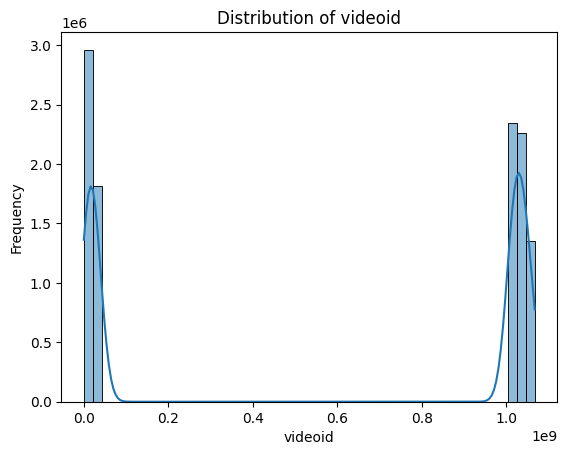

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(full_data['videoid'], kde=True, bins=50)
plt.title('Distribution of videoid')
plt.xlabel('videoid')
plt.ylabel('Frequency')
plt.show()


In [6]:
is_unique =full_data['videoid'].nunique() == len(full_data)
print(f"Is videoid unique? {is_unique}")
if not is_unique:
    print(full_data['videoid'].value_counts().head(10))  # Show top duplicates


Is videoid unique? False
videoid
1066696999    2
1066697260    2
1066676881    2
1065521032    2
1059155453    2
1059150260    2
1062722287    2
1058060785    2
1027554365    2
1065867481    2
Name: count, dtype: int64


In [10]:
# Add a column for quartile-based segmentation
full_data['videoid_segment'] = pd.qcut(full_data['videoid'], 4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
print(full_data.groupby('videoid_segment').size())


videoid_segment
Low         2681902
Mid-Low     2681902
Mid-High    2681901
High        2681902
dtype: int64


C:\Users\acer\AppData\Local\Temp\ipykernel_22460\3622118520.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(full_data.groupby('videoid_segment').size())


In [14]:
print(f"Total duplicate rows: {full_data.duplicated().sum()}")




Total duplicate rows: 0


In [19]:
print(full_data.columns)


Index(['videoid', 'contentUrl', 'duration', 'page_dir', 'name',
       'videoid_segment'],
      dtype='object')


In [18]:
data = full_data.dropna(subset=['videoid'])


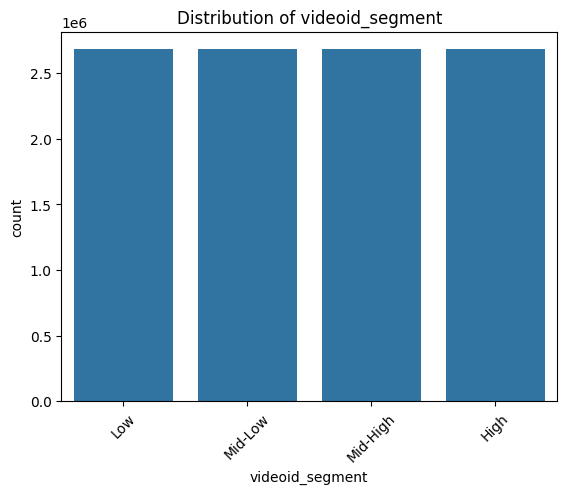

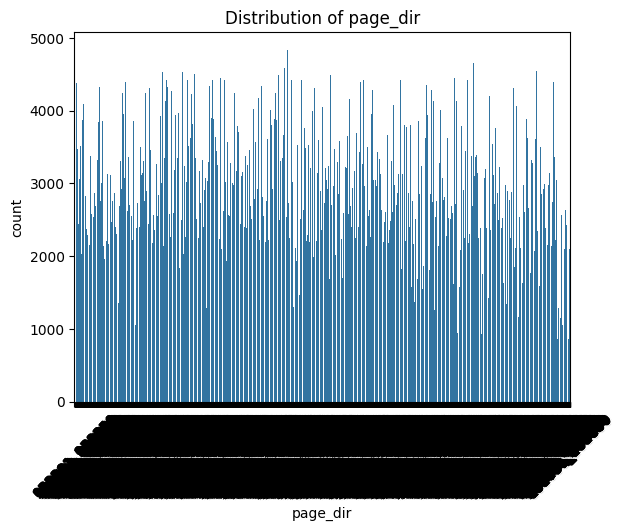

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot for videoid_segment
sns.countplot(data=full_data, x='videoid_segment')
plt.title('Distribution of videoid_segment')
plt.xticks(rotation=45)
plt.show()

# Count plot for page_dir
sns.countplot(data=full_data, x='page_dir')
plt.title('Distribution of page_dir')
plt.xticks(rotation=45)
plt.show()


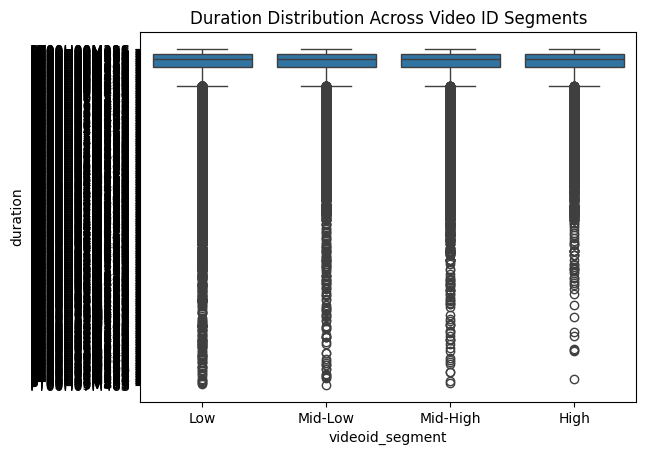

In [24]:
sns.boxplot(x='videoid_segment', y='duration', data=full_data)
plt.title('Duration Distribution Across Video ID Segments')
plt.show()


In [25]:
full_data.groupby('videoid_segment')['duration'].describe()


C:\Users\acer\AppData\Local\Temp\ipykernel_22460\3260315571.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full_data.groupby('videoid_segment')['duration'].describe()


,count,unique,top,freq
videoid_segment,,,,
Low,2681902,397,PT00H00M10S,203576
Mid-Low,2681902,317,PT00H00M10S,207569
Mid-High,2681901,321,PT00H00M10S,219287
High,2681902,244,PT00H00M10S,234774


Each videoid_segment (Low, Mid-Low, Mid-High, High) contains roughly 2.68 million videos, meaning they are evenly distributed.
The number of unique durations decreases as we move from Low (397 unique durations) to High (244 unique durations).
This suggests that higher segments might contain videos with more standardized durations, while lower segments have more variation.
The most common duration across all segments is "PT00H00M10S" (10 seconds).
The frequency of 10-second videos increases from Low (203,576) to High (234,774).
This means that shorter videos are heavily present in all segments, and their presence grows in the higher segments.

In [26]:
full_data['duration_sec'] = full_data['duration'].str.extract('(\d+)').astype(float)
full_data.groupby('videoid_segment')['duration_sec'].mean()


C:\Users\acer\AppData\Local\Temp\ipykernel_22460\714664062.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full_data.groupby('videoid_segment')['duration_sec'].mean()


videoid_segment
Low         1.827062e-05
Mid-Low     6.338785e-06
Mid-High    3.728698e-07
High        0.000000e+00
Name: duration_sec, dtype: float64

The duration_sec values across videoid_segment categories are extremely low, suggesting that the recorded duration values might not be properly extracted or interpreted.
Very Small Duration Values:

"Low" has 1.82e-05 seconds (~0.000018 seconds), which is unrealistic.
"High" has 0.000000e+00, meaning some durations might be missing or incorrectly processed.
Possible Issues:

Duration Extraction Error: If the duration format is "PT00H00M10S" (ISO 8601 format), it needs proper conversion. The extraction might only be capturing the first numeric value (like "00" from hours).
Data Corruption: The dataset might contain missing or incorrectly formatted durations.
Normalization Needed: Values could be incorrectly scaled, requiring adjustments.

In [27]:
import pandas as pd
import re

def convert_duration(duration):
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', duration)
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    return hours * 3600 + minutes * 60 + seconds

full_data['duration_sec'] = full_data['duration'].apply(lambda x: convert_duration(x) if pd.notnull(x) else 0)


In [28]:
full_data.groupby('videoid_segment')['duration_sec'].mean()


C:\Users\acer\AppData\Local\Temp\ipykernel_22460\3035876530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full_data.groupby('videoid_segment')['duration_sec'].mean()


videoid_segment
Low         18.403899
Mid-Low     18.548322
Mid-High    17.872083
High        17.058243
Name: duration_sec, dtype: float64

Segmentation is Not Based Solely on Duration
The High segment (17.06 sec) contains slightly shorter videos on average.
This suggests segmentation might consider additional factors like:
Video popularity
Resolution or quality
Metadata like content type or platform source